In [1]:
import numpy as np

c = np.array([[1,0,0,0,0,0,0]])
w = np.random.randn(7, 3)
h = np.matmul(c, w)
print(h)

[[-0.50415859  0.4640934   0.38801436]]


In [2]:
import sys
sys.path.append('..')
from common.layers import MatMul

c = np.array([[1,0,0,0,0,0,0]])
w = np.random.randn(7 ,3)
layer = MatMul(w)
h = layer.forward(c)
print(h)

[[-1.4004438  -1.44478781  0.1376542 ]]


In [3]:
# 샘플 맥락 데이터
c0 = np.array([[1,0,0,0,0,0,0]])
c1 = np.array([[0,0,1,0,0,0,0]])

# 가중치 초기화
w_in = np.random.randn(7, 3)
w_out = np.random.randn(3, 7)

# 계층 생성
in_layer0 = MatMul(w_in)
in_layer1 = MatMul(w_in)
out_layer = MatMul(w_out)

# 순전파
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)

print(s)

[[-2.18122722  0.38984516 -0.52045281  0.47034006  2.20802098  0.48564491
   1.23857095]]


In [5]:
import sys
sys.path.append('..')
from common.util import preprocess

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
print(corpus)
print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


In [6]:
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []
    
    for idx in range(window_size, len(corpus) - window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)
        
    return np.array(contexts), np.array(target)

In [7]:
contexts, target = create_contexts_target(corpus, window_size=1)

print(contexts)
print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
[1 2 3 4 1 5]


In [8]:
from common.util import preprocess, create_contexts_target, convert_one_hot

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

contexts, target = create_contexts_target(corpus, window_size=1)

vocab_size = len(word_to_id)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

In [10]:
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        v, h = vocab_size, hidden_size
        
        # 가중치 초기화
        w_in = 0.01 * np.random.randn(v, h).astype('f')
        w_out = 0.01 * np.random.randn(h, v).astpye('f')
        
        # 계층 생성
        self.in_layer0 = MatMul(w_in)
        self.in_layer1 = MatMul(w_in)
        self.out_layer = MatMul(w_out)
        self.loss_layer = SoftmaxWithLoss()
        
        # 모든 가중치와 기울기를 리스트에 모은다
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads
            
        # 인스턴스 변수에 단어의 분산 표현을 저장한다
        self.word_vecs = w_in
        
    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss
    
    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None

| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 26 |

| 에폭 520 |  반복 1 / 2 | 시간 0[s] | 손실 0.50
| 에폭 521 |  반복 1 / 2 | 시간 0[s] | 손실 0.50
| 에폭 522 |  반복 1 / 2 | 시간 0[s] | 손실 0.53
| 에폭 523 |  반복 1 / 2 | 시간 0[s] | 손실 0.57
| 에폭 524 |  반복 1 / 2 | 시간 0[s] | 손실 0.57
| 에폭 525 |  반복 1 / 2 | 시간 0[s] | 손실 0.53
| 에폭 526 |  반복 1 / 2 | 시간 0[s] | 손실 0.45
| 에폭 527 |  반복 1 / 2 | 시간 0[s] | 손실 0.52
| 에폭 528 |  반복 1 / 2 | 시간 0[s] | 손실 0.53
| 에폭 529 |  반복 1 / 2 | 시간 0[s] | 손실 0.62
| 에폭 530 |  반복 1 / 2 | 시간 0[s] | 손실 0.40
| 에폭 531 |  반복 1 / 2 | 시간 0[s] | 손실 0.52
| 에폭 532 |  반복 1 / 2 | 시간 0[s] | 손실 0.51
| 에폭 533 |  반복 1 / 2 | 시간 0[s] | 손실 0.57
| 에폭 534 |  반복 1 / 2 | 시간 0[s] | 손실 0.52
| 에폭 535 |  반복 1 / 2 | 시간 0[s] | 손실 0.60
| 에폭 536 |  반복 1 / 2 | 시간 0[s] | 손실 0.44
| 에폭 537 |  반복 1 / 2 | 시간 0[s] | 손실 0.51
| 에폭 538 |  반복 1 / 2 | 시간 0[s] | 손실 0.60
| 에폭 539 |  반복 1 / 2 | 시간 0[s] | 손실 0.43
| 에폭 540 |  반복 1 / 2 | 시간 0[s] | 손실 0.56
| 에폭 541 |  반복 1 / 2 | 시간 0[s] | 손실 0.46
| 에폭 542 |  반복 1 / 2 | 시간 0[s] | 손실 0.60
| 에폭 543 |  반복 1 / 2 | 시간 0[s] | 손실 0.51
| 에폭 544 |  반복 1

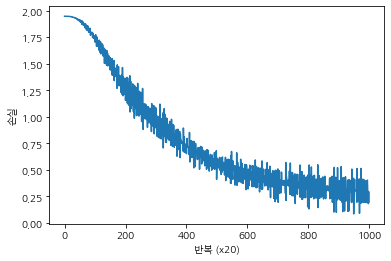

In [14]:
from common.trainer import Trainer
from common.optimizer import Adam
from simple_cbow import SimpleCBOW
from common.util import preprocess, create_contexts_target, convert_one_hot

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

In [16]:
word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

you [-1.0535741 -1.0461274  1.025205   1.6759902 -1.0302869]
say [ 1.3973123   0.09042856 -1.3753312  -0.40898278  0.69815576]
goodbye [-0.98235995 -0.95830613  0.92958087 -0.7772423  -0.92124695]
and [ 1.0405365  1.3517084 -1.0546101 -1.4211398  1.3164047]
i [-0.98301107 -0.9630518   0.9308678  -0.76999766 -0.92511255]
hello [-1.0673139 -1.0402849  1.0305978  1.6702341 -1.0342985]
. [ 0.9758607 -1.4428424 -1.2544938  1.386587  -1.5257115]
